In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -qq langchain-groq langgraph

In [3]:
from kaggle_secrets import UserSecretsClient
from langchain_groq import ChatGroq

user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("GROQ_API_KEY")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=api_key
)

In [4]:
print(llm.invoke("what does http stand for?").content)

HTTP stands for HyperText Transfer Protocol. It's a standard protocol used for transferring data over the internet, particularly for communicating between web servers and web browsers.


In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# Define State

In [6]:
class questionbank(TypedDict):
    topic : str
    que_type : str
    question : str
    approved : bool
    feedback : str

# Define Functions

In [7]:
def generate_que(state : questionbank):
    topic = state["topic"]
    que_type = state["que_type"]
    feedback = state.get("feedback","")

    prompt = f"""
    You are a question bank generator. 
    Generate a question of type : {que_type} based on the topic : {topic}.
    User feedback (if any) : {feedback}
    """

    question = llm.invoke(prompt).content
    return {"question":question, "approved":False}


def human_review(state : questionbank):
    print(f"\nGenerated question on topic : {state["topic"]}")
    print(state["question"])

    approval = input("Approve question? (yes/no) : ")

    if approval == 'yes':
        return {"approved":True}
    else:
        changes = input("Enter changes you want :")
        return {
            "approved" : False,
            "feedback" : changes
        }

def condition(state : questionbank):
    if state["approved"]:
        return "end"
    else :
        return "generate_que"

# Create Graph

In [8]:
graph = StateGraph(questionbank)

graph.add_node("generate_que",generate_que)
graph.add_node("human_review",human_review)

graph.add_edge(START, "generate_que")
graph.add_edge("generate_que","human_review")
graph.add_conditional_edges(
    "human_review",
    condition,
    {
        "generate_que":"generate_que",
        "end":END
    }
)

# Checkpointer to save history

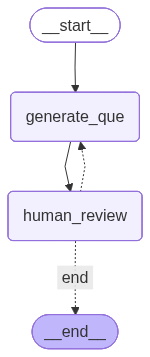

In [9]:
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

# creating thread and invoking the graph

In [10]:
config1 = {"configurable" : {"thread_id" : "que_thread1"}}

initial_state = {
    "topic":"Gravity",
    "que_type":"Fill in the blank"
}

result = workflow.invoke(initial_state, config=config1)

print('-'*100)
print("\nFinal question : ")
for k,v in result.items():
    print(f"{k} : {v}")


Generated question on topic : Gravity
Here's a fill-in-the-blank question based on the topic of Gravity:

The force of gravity is what keeps the planets in our solar system in orbit around the _______________________.


Approve question? (yes/no) :  no
Enter changes you want : make it complex



Generated question on topic : Gravity
Here's a fill-in-the-blank question on the topic of gravity, with a higher level of complexity:

The curvature of spacetime around a massive object, such as a black hole, is a direct result of the _______________________ of mass and energy, as described by the Einstein field equations, which relate the _______________________ of spacetime to the _______________________ of matter and energy, and is a fundamental concept in understanding the phenomenon of gravitational lensing and the bending of light around massive celestial bodies.

(Blank 1: _______________________, Blank 2: _______________________, Blank 3: _______________________)

Note: This question requires a good understanding of general relativity and the mathematical framework that underlies our modern understanding of gravity. 

Answer: (Blank 1: equivalence, Blank 2: geometry, Blank 3: distribution)


Approve question? (yes/no) :  yes


----------------------------------------------------------------------------------------------------

Final question : 
topic : Gravity
que_type : Fill in the blank
question : Here's a fill-in-the-blank question on the topic of gravity, with a higher level of complexity:

The curvature of spacetime around a massive object, such as a black hole, is a direct result of the _______________________ of mass and energy, as described by the Einstein field equations, which relate the _______________________ of spacetime to the _______________________ of matter and energy, and is a fundamental concept in understanding the phenomenon of gravitational lensing and the bending of light around massive celestial bodies.

(Blank 1: _______________________, Blank 2: _______________________, Blank 3: _______________________)

Note: This question requires a good understanding of general relativity and the mathematical framework that underlies our modern understanding of gravity. 

Answer: (Blank 1: equiva

# view history

In [11]:
history = workflow.get_state_history(config1)

for state in history:
    print('-'*100)
    for k,v in state.values.items():
        print(f"{k} : {v}")

----------------------------------------------------------------------------------------------------
topic : Gravity
que_type : Fill in the blank
question : Here's a fill-in-the-blank question on the topic of gravity, with a higher level of complexity:

The curvature of spacetime around a massive object, such as a black hole, is a direct result of the _______________________ of mass and energy, as described by the Einstein field equations, which relate the _______________________ of spacetime to the _______________________ of matter and energy, and is a fundamental concept in understanding the phenomenon of gravitational lensing and the bending of light around massive celestial bodies.

(Blank 1: _______________________, Blank 2: _______________________, Blank 3: _______________________)

Note: This question requires a good understanding of general relativity and the mathematical framework that underlies our modern understanding of gravity. 

Answer: (Blank 1: equivalence, Blank 2: geo

# create another thread in different config(session)

In [12]:
config2 = {"configurable" : {"thread_id" : "que_thread2"}}

initial_state = {
    "topic":"CNN",
    "que_type":"True or False"
}

result = workflow.invoke(initial_state, config=config2)

print('-'*100)
print("\nFinal question : ")
for k,v in result.items():
    print(f"{k} : {v}")


Generated question on topic : CNN
Here's your True or False question:

**Question:** True or False: CNN (Convolutional Neural Network) is primarily used for Natural Language Processing tasks.

**A)** True
**B)** False

Let me know if you need any help or clarification!


Approve question? (yes/no) :  yes


----------------------------------------------------------------------------------------------------

Final question : 
topic : CNN
que_type : True or False
question : Here's your True or False question:

**Question:** True or False: CNN (Convolutional Neural Network) is primarily used for Natural Language Processing tasks.

**A)** True
**B)** False

Let me know if you need any help or clarification!
approved : True


# continuing in same config

In [13]:
initial_state = {
    "topic":"Machine Learning",
    "que_type":"True or False"
}

result = workflow.invoke(initial_state, config=config2)

print('-'*100)
print("\nFinal question : ")
print(result)


Generated question on topic : Machine Learning
Here's a True or False question based on the topic of Machine Learning:

**Question:** True or False: The primary goal of supervised learning in machine learning is to make predictions on unlabeled data.

**Correct Answer:** FALSE (The primary goal of supervised learning is to make predictions on labeled data, where the model is trained on a dataset with input-output pairs to learn the relationship between them.)

Let me know if you need any more questions or have any specific feedback!


Approve question? (yes/no) :  yes


----------------------------------------------------------------------------------------------------

Final question : 
{'topic': 'Machine Learning', 'que_type': 'True or False', 'question': "Here's a True or False question based on the topic of Machine Learning:\n\n**Question:** True or False: The primary goal of supervised learning in machine learning is to make predictions on unlabeled data.\n\n**Correct Answer:** FALSE (The primary goal of supervised learning is to make predictions on labeled data, where the model is trained on a dataset with input-output pairs to learn the relationship between them.)\n\nLet me know if you need any more questions or have any specific feedback!", 'approved': True}


# history for config2

In [14]:
history = workflow.get_state_history(config2)

for state in history:
    print('-'*100)
    print(state)

----------------------------------------------------------------------------------------------------
StateSnapshot(values={'topic': 'Machine Learning', 'que_type': 'True or False', 'question': "Here's a True or False question based on the topic of Machine Learning:\n\n**Question:** True or False: The primary goal of supervised learning in machine learning is to make predictions on unlabeled data.\n\n**Correct Answer:** FALSE (The primary goal of supervised learning is to make predictions on labeled data, where the model is trained on a dataset with input-output pairs to learn the relationship between them.)\n\nLet me know if you need any more questions or have any specific feedback!", 'approved': True}, next=(), config={'configurable': {'thread_id': 'que_thread2', 'checkpoint_ns': '', 'checkpoint_id': '1f121be0-a309-6c13-8006-68ccd77622a7'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-03-17T04:59:12.365647+00:00', parent_config={'configurable': {'thread_id'

# Resuming from previous state

In [17]:
workflow.get_state({'configurable': {'thread_id': 'que_thread2', 'checkpoint_id': '1f121bdf-e0e6-66ac-8005-63d070bdc98a'}})

StateSnapshot(values={'topic': 'Machine Learning', 'que_type': 'True or False', 'question': "Here's a True or False question based on the topic of Machine Learning:\n\n**Question:** True or False: The primary goal of supervised learning in machine learning is to make predictions on unlabeled data.\n\n**Correct Answer:** FALSE (The primary goal of supervised learning is to make predictions on labeled data, where the model is trained on a dataset with input-output pairs to learn the relationship between them.)\n\nLet me know if you need any more questions or have any specific feedback!", 'approved': False}, next=('human_review',), config={'configurable': {'thread_id': 'que_thread2', 'checkpoint_id': '1f121bdf-e0e6-66ac-8005-63d070bdc98a'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-03-17T04:58:52.008794+00:00', parent_config={'configurable': {'thread_id': 'que_thread2', 'checkpoint_ns': '', 'checkpoint_id': '1f121bdf-db28-6e6a-8004-c73ca86c84fd'}}, tasks=(Pr

In [18]:
result = workflow.invoke(
    {
        "approved": False,
        "feedback": "make it more complex and confusing"
    },
    config=config2
)

print('-'*100)
print("\nFinal question : ")
for k,v in result.items():
    print(f"{k} : {v}")


Generated question on topic : Machine Learning
Here's a True or False question on Machine Learning that's a bit more complex and confusing:

True or False: In a scenario where a neural network is trained using a stochastic gradient descent optimizer with a learning rate of 0.01 and a momentum of 0.9, and the network is regularized using dropout with a dropout rate of 0.2, if the network is then fine-tuned on a smaller dataset with a different distribution than the original training dataset, but the fine-tuning process uses a different optimizer, such as Adam, with a learning rate of 0.001 and a weight decay of 0.0001, it is guaranteed that the network will not suffer from catastrophic forgetting of the original task, assuming that the fine-tuning dataset is sufficiently small and the original task is a classification problem with a large number of classes.

Think you can handle it?


Approve question? (yes/no) :  yes


----------------------------------------------------------------------------------------------------

Final question : 
topic : Machine Learning
que_type : True or False
question : Here's a True or False question on Machine Learning that's a bit more complex and confusing:

True or False: In a scenario where a neural network is trained using a stochastic gradient descent optimizer with a learning rate of 0.01 and a momentum of 0.9, and the network is regularized using dropout with a dropout rate of 0.2, if the network is then fine-tuned on a smaller dataset with a different distribution than the original training dataset, but the fine-tuning process uses a different optimizer, such as Adam, with a learning rate of 0.001 and a weight decay of 0.0001, it is guaranteed that the network will not suffer from catastrophic forgetting of the original task, assuming that the fine-tuning dataset is sufficiently small and the original task is a classification problem with a large number of classe

# updated history

In [19]:
history = workflow.get_state_history(config2)

for state in history:
    print('-'*100)
    print(state)

----------------------------------------------------------------------------------------------------
StateSnapshot(values={'topic': 'Machine Learning', 'que_type': 'True or False', 'question': "Here's a True or False question on Machine Learning that's a bit more complex and confusing:\n\nTrue or False: In a scenario where a neural network is trained using a stochastic gradient descent optimizer with a learning rate of 0.01 and a momentum of 0.9, and the network is regularized using dropout with a dropout rate of 0.2, if the network is then fine-tuned on a smaller dataset with a different distribution than the original training dataset, but the fine-tuning process uses a different optimizer, such as Adam, with a learning rate of 0.001 and a weight decay of 0.0001, it is guaranteed that the network will not suffer from catastrophic forgetting of the original task, assuming that the fine-tuning dataset is sufficiently small and the original task is a classification problem with a large n